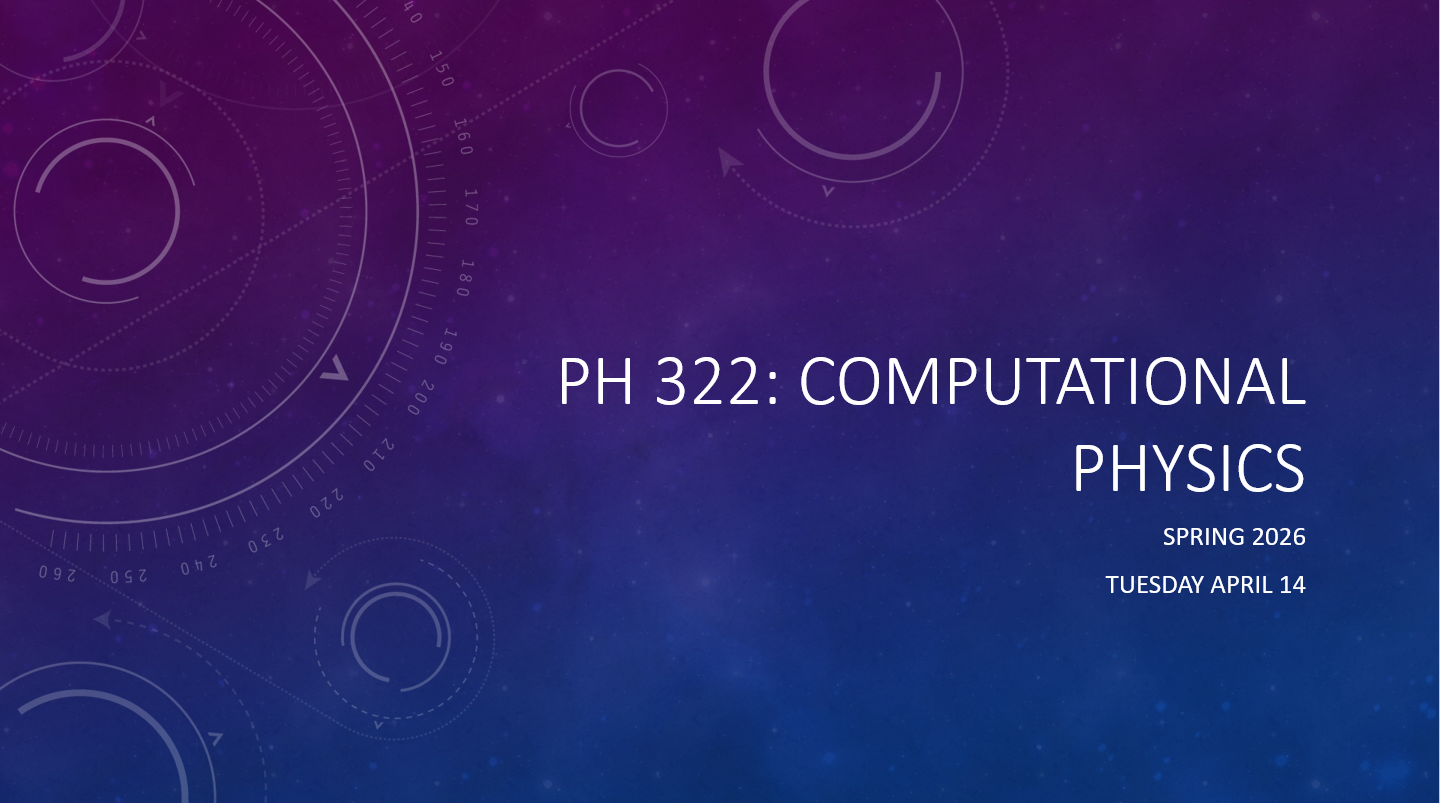

In [1]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture5.png"))

**Announcements**
* HW1 is graded. Average score was 46.3/50. We left grading comments in your code using the # !!! syntax. 
* A few comments after grading HW1:
 + Comment, comment, comment
 + If a variable contains a physical quantity, include units of the quantity in the comments.
 + Use white space between lines of code when needed to improve readability.
 + If you lost points because the image of your derivation in the first problem didn't display, email me your image and I will add points. 
 + Before submitting your HW notebook, restart the kernel, and rerun code in each cell.  In some cases, there were undefined variables which likely means students ran a previous version of the code and stored the variable in memory, but then removed it in a later version of the code.
 + Only use functions and modules we have gone over in class.
 + You need to document your use of AI. One of you wrote that after struggling with the problem on your own, you used AI. That's fine. Also explain how AI fixed your problem, or what AI did differently. Basically, I want you to understand what AI is giving you, not just trust it blindly.
* HW2 due tonight.


**Last Class**
* User-defined functions  
* Reading in data from a file
* Making plots with matplotlib.pyplot
* pandas 

**Today**
* Graphics and animation with the ```qdraw``` package
* Numerical limitations
* Overflow/underflow
* Floating point precision
* Rounding errors
* Program speed

Notes
* The first edition of our textbook uses the ```vpython``` package for graphics and animation. I have a "vpython" version of this lecture notebook that reviews ```vpython```. For the future, you can use either ```vpython``` or ```qdraw``` for graphics and animation. 
* If your ```vpython``` or ```qdraw``` graphics window hangs, restart the Python kernel. This will remove any variables and objects currently stored in memory. 




### ```qdraw```  package

We can draw and animate objects like circles, squares and lines using the ```qdraw``` package.   ```qdraw``` was written by our textbook author and uses the ```turtle``` graphics engine.

To use ```qdraw``` you will need to download [qdraw.py](https://public.websites.umich.edu/~mejn/cp2/programs/qdraw.py) from the author's website and place in your Python working directory. I also placed a copy on Canvas in the Data and Python Files module. 

Complete documentation about ```qdraw``` is in Appendix B of the second edition.  

Once you have placed the file in your working directory, you import ```qdraw``` like any other package:

```
import qdraw 
```

or:

```
import qdraw  as qd
```

or if you wish to import individual functions (probably safe as these will not likely duplicate functions from other packages):

```
from qdraw import <function_name>
```

### window()

To draw an object, we first need to create a drawing window using the ```window()``` function. The definition for the ```window()``` is:

```
window(width=1000, height=1000, xlim=(0,1), ylim=(0,1), position=(0,0), bgcolor="white", title="My Title")
```

* ```width``` = width of window in pixels
* ```height``` = height of window in pixels
* ```xlim``` = range of x coordinates for the horizontal axis
* ```ylim``` = range of y coordinates for the vertical axis
* ```position``` = position of the window on the screen
* ```bgcolor``` = background color
* ```title``` = window title

To avoid distortion it is recommended to specify only three of the four parameters ```width, height, xlim, ylim```, and let ```qdraw``` determine the fourth. 

After you create the window you can draw a number of shapes using the following functions:

* ```circle(size, pos, color, olcolor, olwidth, pixelsize)```
* ```square(size, pos, color, olcolor, olwidth, pixelsize)```
* ```rectangle(left, right, bottom, top, pos, color, olcolor, olwidth, pixelsize)```
* ```ellipse(width, height, pos, color, olcolor, olwidth, pixelsize)```
* ```polygon(path, pos, color, olcolor, olwidth, pixelsize)```

Most of these parameters are self-explanatory. When drawing a circle, ```size``` is the diameter of the circle, and ```pos``` is a tuple that contains the coordinates of the center of the circle.

By default you specify distances in coordinates based on how you defined the window coordinates in your ```window``` function. If you wish to set distances in pixels, set ```pixelsize=True```.

See ```qdraw``` documentation for information about other parameters. 

### Drawing a circle 

To draw a circle, we first create a window, then use the ```circle()``` function to draw the circle. 

We will create a window with width=1000 pixels that spans x=(-20,20) and y=(-10,10).  ```qdraw``` will automatically calculate the height in pixels.

Next we draw a red circle with diameter=10 at the center of the window. Diameter=10 means the circle will span 10 coordinate units. Since x goes from -20, 20, we expect the circle to cover about one quarter of the horizontal axis, and about one half of the vertical axis.

The circle is created in memory. To display it, we need to use the ```show()``` function, which creates a graphics window and displays the circle. Python will pause here until you close the graphics window. 

In [ ]:
import qdraw as qd

# create a window 1000 pixels wide. The x-axis spans coordinates -1,1 and the y-axis spans -5 to 5. qdraw will automatically determin
# the number of pixels in the vertical direction to keep the aspect in both dimensions equal
window = qd.window(width=1000, xlim=(-20,20), ylim=(-10,10),title="qdraw window")

# create a circle
qd.circle(size=10, pos=(0,0), color="red")

# Display the circle in a graphics window.
# Program pauses here until graphics window is closed. 
qd.show()

print("hello")

Note: In Jupyter notebook, you can only run a cell once that uses ```show```. 


Another option to display the graphic is the ```draw``` function. Unlike ```show``` , your code will continue executing past ```draw()```.

In [ ]:
import qdraw as qd

# create a window 1000 pixels wide. The x-axis spans coordinates -1,1 and the y-axis spans -5 to 5. qdraw will automatically determin
# the number of pixels in the vertical direction to keep the aspect in both dimensions equal
window = qd.window(width=1000, xlim=(-20,20), ylim=(-10,10),title="qdraw window")

# create a circle
qd.circle(size=10, pos=(0,0), color="red")

# Using draw() function to display graphics. The program continues execution without needing to close the window. 
qd.draw()

print("hello")

We can draw a rectangle using the ```qdraw``` ```rectangle()``` function:

In [ ]:
import qdraw as qd

qd.window(width=1000, xlim=(-20,20), ylim=(-10,10),title="qdraw window")
qd.rectangle(left=-10, right=10, bottom=-5, top=5, color="blue")
qd.draw()

Here we specific the coordinates of each side of the rectangle.

Each object is its own Python object type. For example, a rectangle is a rectangle object. For example, let's assign a variable the output of the ```rectangle``` function, and print its type:

In [ ]:
import qdraw as qd

qd.window(width=1000, xlim=(-20,20), ylim=(-10,10))

rect = qd.rectangle(left=-10, right=10, bottom=-5, top=5, color="blue")

print(type(rect))

Each ```qdraw``` shape we create is a Python object with properties such as size and color we can change, using the property after the object name with a period after it's created. 

For example, we change the position of the rectangle using the ```setpos``` property:

In [ ]:
import qdraw as qd

qd.window(width=1000, xlim=(-20,20), ylim=(-10,10))

rect = qd.rectangle(left=-5, right=2, bottom=-2, top=2, pos=(0,0), color="blue")
rect.setpos(-5,5)

qd.draw()


**Animations**

We can create simple animations by changing abd object's position in a loop. For example, here I create four circles outside the ```for``` loop, then change the positions of two circles inside the ```for``` loop using the ```setpos()``` method. 

In [ ]:
import qdraw as qd

qd.window(width=1000, xlim=(-20,20), ylim=(-10,10))

# create 4 circles 
r = qd.circle(color="red", size=5, pos=(-15,0))
b1 = qd.circle(color="blue", size=5, pos=(0,0))
b2 = qd.circle(color="blue", size=5, pos=(0,0))
r = qd.circle(color="red", size=5, pos=(15,0))

# Change the positions of the red and blue spheres everytime through
# the loop. Use the rate() function to control the frame rate.
for i in range (1500):
    # increment the positions of the b1 and b2 circles
    b1.setpos(i*0.01, 0)
    b2.setpos(-i*0.01, 0)
    qd.draw(0.005) # here I tell qdraw to pause 0.005 sec before advancing

```qdraw(<time>)```

You can tell ```qdraw``` to pause between frames to slow the animation by providing the pause time in seconds within the ```draw``` function. 


Since ```qdraw``` objects are Python objects, we can create an array of ```qdraw``` shapes using numpy:

In [ ]:
import numpy as np
import qdraw as qd

qd.window(width=1000, xlim=(-20,20), ylim=(-10,10))

# create an empty array of object type circle
a = np.empty(10, qd.circle)

# fill the array with alternating red and blue circles with incremented position and radii
for i in range(10):
    # if i is odd, make a red circle
    if i%2 == 1:
        a[i]=qd.circle(color="red", size=4, pos=(-18 + i*4, 0))
    # if i is even, make a blue circle
    else:
        a[i]=qd.circle(color="blue", size=4, pos=(-18 + i*4, 0))
qd.draw()


In [ ]:
import qdraw as qd
import matplotlib.pyplot as plt

qd.window(xlim=(-100,100), ylim=(0,100))

# draw a block building
building = qd.rectangle(pos=(0,0), left=-20, right=0, bottom=0, top=80, color="blue")

# Draw front windows in xy-plane
for ypos in range(5,80,7):
    for xpos in range(-17,0,7):
        window = qd.rectangle(pos=(xpos,ypos), left=-2, right=2, bottom=0, top=5, color="black")

# add the ground
ground = qd.rectangle(pos=(0,0),left=-100, right=100, bottom=0, top=2, color="green")

# create the falling ball and place at top of building
ball = qd.circle(pos=(20,80), size=3, color="red")

# define constants and initial conditions
g = 9.81 # m/s^2
m = 10 # mass of objecct, kg (not really needed because mass cancels out)
p = 0 # initial y-momentum, kg m/s
y = 80 # initial y-position of object, in pixels
t = 0 # initial time
deltat = 0.01 # time step, s
times=[t] # list to store times
height=[y] # list to store heights of object
velocity=[p/m] # list to store velocity of object

# loop until object hits the ground
while y >= 0:
    
    # calculate current momentum
    p = p - m*g*deltat
    # calculate current position
    y = y + (p/m)*deltat
    # update the y-position of the object
    ball.setpos(20,y)
    # increment time 
    t = t + deltat
    # store variables for plotting
    times.append(t)
    height.append(y)
    velocity.append(p/m)
    qd.draw(0.005)
    
    
plt.plot(times, height)
plt.xlabel('Time, s')
plt.ylabel('Height, m')
plt.show()
plt.plot(times,velocity)
plt.xlabel('Time, s')
plt.ylabel('Velocity, m/s')
plt.show()


### Numerical precision   

We've now finished our introduction to the Python language and will soon get into numerical methods commonly used in physics. 

Chapter 4 is about some of the limitations we face when doing numerical calculations, limitations of numerical accuracy and speed. 

To start our discussion let's look what happens when we run the following two blocks of code written for *Exercise 4.1.*

**Exercise 4.1 Factorial function** 

Write a program to calculate and print the factorial of a number entered by the user.

We first write the program so it calculates the factorial using
integer variables. We will use it to calculate the factorial of 180.

$$
n! = \prod_{k=1}^{n}k
$$



In [ ]:
# Use the factorial function from section 2.6
import numpy as np

# Calculate factorial using integers
def ifactorial(n):
    # by initializing f as an integer, the product will remain an integer.  
    f = 1
    #loop over 1,...,n
    for k in range(1, n+1):
        f *= k
    return f

n = int(input("Enter number: "))
nfact = ifactorial(n)
print (f"{n}! = {nfact}")

Now I will modify my program to calculate the factorial using a float.  Again I will calculate the factorial of 180. What do we find? 

In [ ]:
# Calculate factorial using floats
def ffactorial(n):
    # by initializing f as a float, the factorial will be a float
    f = 1.0 
    # loop over 1,...,n
    for k in range(1, n+1):
        f *= k
    return f

i = int(input("Enter number: "))
nfact = ffactorial(i)
print (f"{i}! = {nfact}")

You see when we try to calculate the factorial of 180 using floats, we get *inf*. What does this mean, and why the difference between floats and integers? 

### Overflows and underflows

*inf* means we have exceeded the highest floating point number that Python is able to store, which is about $\pm 10^{308}$. 

This is due to the limit of 64 bits that Python uses to store floating point numbers and how the bits are partitioned between the precision and range of a float.  

Any number greater  than $1.8\times 10^{308}$ (or less than $-1.8\times 10^{308}$) is an *overflow* which Python indicates by assigning an *inf* value. 


In [ ]:
f=1.7e308
f

In [ ]:
f=3.6e308
f

In [ ]:
f=-3.6e308
f

Likewise, the smallest floating point number Python can store is about $\pm 10^{-308}$. (Actually the denormalized min is ~ $10^{-323}$) Anything less Python stores as zero. 

These limits usually don't impose any problems, but it's good to be aware of them.



In [ ]:
f=1.2e-320
f

In [ ]:
f = 5.1e-330
f

We can use the *numpy* function np.finfo() to find the limits and precision of floating point numbers: 

In [ ]:
#use function np.finfo to find out float precision

import numpy as np
print(np.finfo(np.float64))

### Integers

Unlike floats, Python can store integers of arbitrary size with exact presicision. The only limitation is the amount of memory your computer has. How Python stores integers is beyond the scope of our course but if interested, you can find a description here:

[Integer representation](https://rushter.com/blog/python-integer-implementation/)

Python can store integers to arbitrary precision as this example shows:

In [ ]:
i = 1234567890123456789012345678901234567890123456789012345678901234567890123456789
i

How about floats? Let's try to store the 20 significant digits as we did in the integer i:

In [ ]:
f =  1234567890123456789012345678901234567890123456789012345678901234567890123456789.
print(f"{f:.18e}")

If you look carefully, the numeral in the 18th decimal place is different than how it was originally defined. 

### Error constant C 

If we look at the output of *np.finfo()*, the precision which Python can store a float is specified by *eps*: 


In [ ]:
print(np.finfo(np.float64))

We see that eps = $2.2e-16$ This epsilon is what our textbook calls the error constant *C*, so we will use that notation:  

$
C \sim 10^{-16}.
$


Because of the error constant, each float will have a rounding error that we call epsilon, or    $\epsilon$.  

For a floating point variable *x*, $\epsilon$ is defined as:

*true value* of float x = x + $\epsilon$ 

The size of the rounding error $\epsilon$ is determined by *C* and the value of the float *x*: 

$\epsilon \sim Cx$

For example:

If $x = 10^{16}$, $\epsilon \sim (10^{-16})({10^{16}}) = 1$.  
If $x = 1$, $\epsilon \sim (10^{-16})(1) = 10^{-16}$.

In [ ]:
# example of rounding error in a small number
a=11.1
b=10.0

# we expect the difference x to be 0.1. 
x = a-b

# due to rounding error it isn't exactly 0.1
print(x)

Here the true value of $(a-b)$ is 1.1 and so the error is 0.0000000000000004 or $4\times10^{-16}$. This is about $1.1C \sim 10^{-16}$.

We can think of the error $\epsilon$ to be randomly distributed about zero with a standard deviation $\sigma$, where $\sigma = Cx$.  We can visualize the distribution of $\epsilon$ for any value of $x$ with this code: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = float(input("Enter a float x: "))

# grab the error constant from numpy function finfo()
C = np.finfo(np.float64).eps
sigma = C*x
print("standard deviation = {:.2e}".format(sigma))

mu = 0 # mean 
s = np.random.normal(mu, sigma, 10000)
count, bins, ignored = plt.hist(s, 30, density=True)
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) *
               np.exp( - (bins - mu)**2 / (2 * sigma**2) ),
         linewidth=2, color='r')

plt.xlabel("Error $\epsilon$")
plt.ylabel("Frequency")
plt.show()

Of course we don't know the exact value of the error, it could be positive or negative, and may be relatively small or large. 

### Rounding errors on differences

Rounding errors can be a problem when we subtract two numbers that are close in value such that the difference between them is small relative to the numbers themselves, as this next example illustrates. 


We define $y$ to be close to but not quite equal to 1:

$$
x = 1
$$
$$
y = 1+10^{-14}
$$



Then $y-x$ is:

$
y-x = 10^{-14}
$

and if divide both sides by $10^{-14}$ we get:


$$
10^{14}(y-x)=1
$$

Both sides of the equation should be equal. Are they? Let's see. 

In [ ]:
from math import sqrt

# define x and y
x = 1.
y = 1.+(1e-14)

rhs = 1

# calculate the lhs:
lhs = (1e14)*(y-x)

# define the relative error between them
relative_err = 100*(lhs-rhs)/rhs

print(f"Right-hand side = {rhs}")
print(f"Left-hand side = {lhs}")
print(f"The relative error is = {relative_err:.2f}%.")



We see the relative error on the difference is 0.08%.  A far cry from the 16 decimal places of accuracy a single float can have.  This happened because the difference is close to the size of the numerical error, which produces a relatively large error.  

So be careful when subtracting two floats of similar size. 

### Do not test for an equality condition using floats

What do you expect this code to output?

In [ ]:
a = 2.0
b = 1.1
c = a-b

if c==0.9:
    print("c=0.9")
else:
    print("c != 0.9")

We expect c to equal 0.9 exactly. But does it?

In [ ]:
print(c)

Because of rounding error it's not quite 0.9. Because of this the logical expression in the *if*-statement is FALSE, so the indented line will not be executed.

It is bad practice generally to test for equality with a float. Because of rounding errors the equality condition may not be met when you expect it to.

Instead you can test to see if a value is close to its expected value, like this:

In [ ]:
a = 2.0
b = 1.1
c = a-b

error= 1e-9
if abs(c-0.9)<error:
    print(f"c=0.9 within {error} error.")
else:
    print("c=0.9 is not within {error} error.")

Now we test to see if the difference between the variable and its expected value is within a small error that we specify. 

## Program speed

This next section will give you a feeling for how fast your code is, i.e., how many operations $N$ are feasible for you to calculate within a reasonable amount of time. And what is the trade-off between accuracy and $N$?

We will use quantum simple harmonic oscillator example from (Example 4.2) from the text to investigate the speed of our program, which includes two sums over infinite series.  

The oscillator has energy levels given by $E_n = \hbar\omega(n+1/2)$.

The average energy of the oscillator is:

$$
E=\frac{1}{Z}\sum^{\infty}_{n=0}E_n e^{-\beta E_n},
$$

where $\beta = 1/(k_B T)$, and 

$$
Z = \sum^{\infty}_{n=0}e^{-\beta E_n}.
$$


Let's vary the number of terms we include in the sum and measure the time it takes to calculate the energy using the *time* module:


In [ ]:
# Example 4.2 Quantum harmonic oscillator at finite temperature

from math import exp
import time

# beta = 1/(k_B T)
beta = 1/100. 

hbar = 1
omega = 1

# initialize both Z and E to 0 since we calculate a sum
Z = 0
E = 0

# Define the number of iterations, N. 
# Need to convert to integer for use in range() function, since scientific notation produces floats
N = int(float(input("Enter the number of iterations: ")))

start = time.time()
# calculate Z
for n in range(N+1):
    E_n = hbar*omega*(n+0.5)
    Z += exp(-beta*E_n)

# calculate main summation
for n in range(N+1):
    E_n = hbar*omega*(n+0.5)
    E += E_n*exp(-beta*E_n)

end = time.time()
      
# calculate the average energy <E>
E /= Z

print(f"It took {end-start:0.2f} seconds for {N:1e} computations")



When I run this for different N, I get the following

|N | time(s) |
|:-|---------|
|1e8|89.3
 |2e7| 16.8|
|1e7| 8.7|
|5e6| 4.0|
|1e6| 0.8|

This tells us a cpl things. First, doing a million operations is pretty fast. A little less than a second. The time scales relatively linearly with $N$, so 10 million operations take about 9 seconds, and 100 million operations take about 90 seconds. I didn't try, but I assume a billion operations would take about 15 minutes, and a trillion operations ($N=1e12$) would take about 11 days. 

So if you want your program to finish in a cpl minutes or less, don't do anymore than about 100 million operations.

Can we improve speed? Well for starters we could combine the two *for*-loops into one since they both loop over the same range. Let's see if that saves us any time.

**Program 2**

In [ ]:
from math import exp
import time

# beta = 1/(k_B T)
beta = 1/100. 

hbar = 1
omega = 1

# initialize both Z and E to 0 since we calculate by summing
Z = 0
E = 0

# Define the number of iterations, N. 
# Need to convert to integer for use in range() function, since scientific notation produces floats
N = int(float(input("Enter the number of iterations: ")))

start = time.time()
# calculate <E>
for n in range(N+1):
    E_n = hbar*omega*(n+0.5)
    Z += exp(-beta*E_n)
    E += E_n*exp(-beta*E_n)
end = time.time()
      
E /= Z

print(f"It took {end-start:0.2f} seconds for {N:1e} computations")

Now I get:

|N | time(s) |
|:-|---------|
|2e7| 15.8|
|1e7| 7.9|


So I save a bit of time, but not too much.

I also notice that I only need to calculate $-\beta E_n$ once since it is the same in the expression for Z and E. In fact both $E$ and $Z$ contain the same exponential function, so only need to calculate that once. 

Program 3

In [ ]:
from math import exp
import time

# beta = 1/(k_B T)
beta = 1/100. 

hbar = 1
omega = 1

# initialize both Z and E to 0 since we calculate by summing
Z = 0
E = 0

# Define the number of iterations, N. 
# Need to convert to integer for use in range() function, since scientific notation produces floats
N = int(float(input("Enter the number of iterations: ")))

start = time.time()
# calculate <E>
for n in range(N):
    E_n = hbar*omega*(n+0.5)
    A = exp(-beta*E_n)
    Z += A
    E += E_n*A
end = time.time()
      
E /= Z

print(f"It took {end-start:0.2f} seconds for {N:1e} computations")

Now I get:

|N | time(s) |
|:-|---------|
|2e7| 10.8|


That's about 30% faster than my program 1. So with just a little bit of work I can make my code more efficient.

We will see that many numerical methods require us to choose a value for $N$. Typically the larger $N$ is, the more accurate our result will be.

Is it worth the time to increase $N$? If we find that the accuracy plateaus at some $N$, then we know there is no need to increase it.

Let's see how our result from changes as we increase $N$: 

In [ ]:
import matplotlib.pyplot as plt
from math import log

# beta = 1/(k_B T)
beta = 1/100. 

hbar = 1
omega = 1

# initialize both Z and E to 0 since we calculate by summing
Z = 0
E = 0

# Need to convert to integer to use in range() function. 
#Scientific notation produces floats
Nmax = int(1e4)
x=[]
y=[]
for N in range(1,Nmax,100):
    E=Z=0
    # calculate <E>
    for n in range(N):
        E_n = hbar*omega*(n+0.5)
        A = exp(-beta*E_n)
        Z += A
        E += E_n*A
    E /= Z
    x.append(N)
    y.append(E)
plt.plot(x,y, 'ro', ms=1.2)
plt.xscale("log")
plt.xlabel("N")
plt.ylabel("<E>")
    

print("E= {}".format(E))

I see that after N=1000 I see little improvement in accuracy. Here's a table showing my results for N=1million, 10 million, and 100 million. 

|N | time(s) | E|
|:-|---------|--:|
|1e6| 1.3| 100.00083333194436|
|1e7| 7.9| 100.00083333194436|
|1e8|72.5|100.00083333194436|

Results are identical even though the time increased 70-fold.  So this is a good lesson to test a few values of $N$ before starting a long run with a large $N$. 